In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset into a Pandas DataFrame
df = pd.read_csv('heart.csv')

df.head()

# Check for missing or 'null' values in every single column
print("Missing Values per Column:")
print(df.isnull().sum())

# Check the data types to ensure everything is a number (int or float)
df.info()

# age: The patient's age in years.
# sex: The patient's gender (1 = Male, 0 = Female).
# cp: Chest Pain type. It is categorized from 0 to 3, representing different types of chest pain (e.g., typical angina, atypical angina, non-anginal pain, or asymptomatic).
# trestbps: Resting blood pressure (in mm Hg) when the patient was admitted to the hospital.
# chol: Serum cholesterol level in mg/dl.
# fbs: Fasting blood sugar. If it is higher than 120 mg/dl, this is 1 (True). If it is lower, it is 0 (False).
# restecg: Resting electrocardiographic (ECG) results. Categorized from 0 to 2 based on the normality of the reading.+
# thalach: Maximum heart rate the patient achieved during testing.
# exang: Exercise-induced angina (chest pain caused by working out). 1 = Yes, 0 = No.
# oldpeak: ST depression induced by exercise relative to rest. (A technical measurement taken from an ECG graph).
# slope: The slope of the peak exercise ST segment (another technical ECG measurement).
# ca: Number of major blood vessels (0 to 4) colored by fluoroscopy.
# thal: A blood disorder called Thalassemia (usually categorized as 1 = normal, 2 = fixed defect, 3 = reversible defect).
# target: The final diagnosis. 1 = Heart Disease is present, 0 = No Heart Disease.

Missing Values per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 

In [4]:
# How many patients have heart disease vs. how many do not ->
print("Target Variable Distribution (1 = Disease, 0 = No Disease):")
print(df['target'].value_counts())

Target Variable Distribution (1 = Disease, 0 = No Disease):
target
1    526
0    499
Name: count, dtype: int64
----------------------------------------


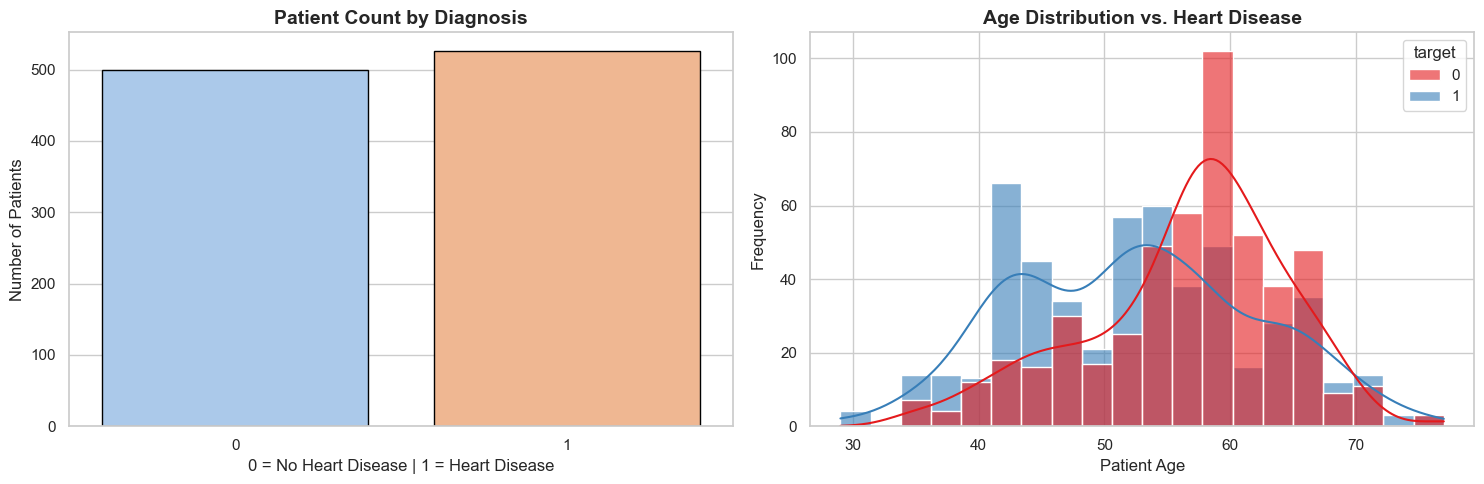

In [6]:
# Age & Disease Distribution ->

sns.set_theme(style="whitegrid")
# Create a canvas with 1 row and 2 columns for side-by-side charts
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: The Target Balance 
# A simple bar chart counting sick vs healthy patients
sns.countplot(data=df, x='target', palette='pastel', ax=ax[0], edgecolor='black', hue='target',legend=False)
ax[0].set_title("Patient Count by Diagnosis", fontsize=14, fontweight='bold')
ax[0].set_xlabel("0 = No Heart Disease | 1 = Heart Disease")
ax[0].set_ylabel("Number of Patients")

# Chart 2: Age Distribution by Diagnosis
# A histogram showing the ages, color-coded by whether they have the disease
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True, palette='Set1', ax=ax[1], alpha=0.6)
ax[1].set_title("Age Distribution vs. Heart Disease", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Patient Age")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

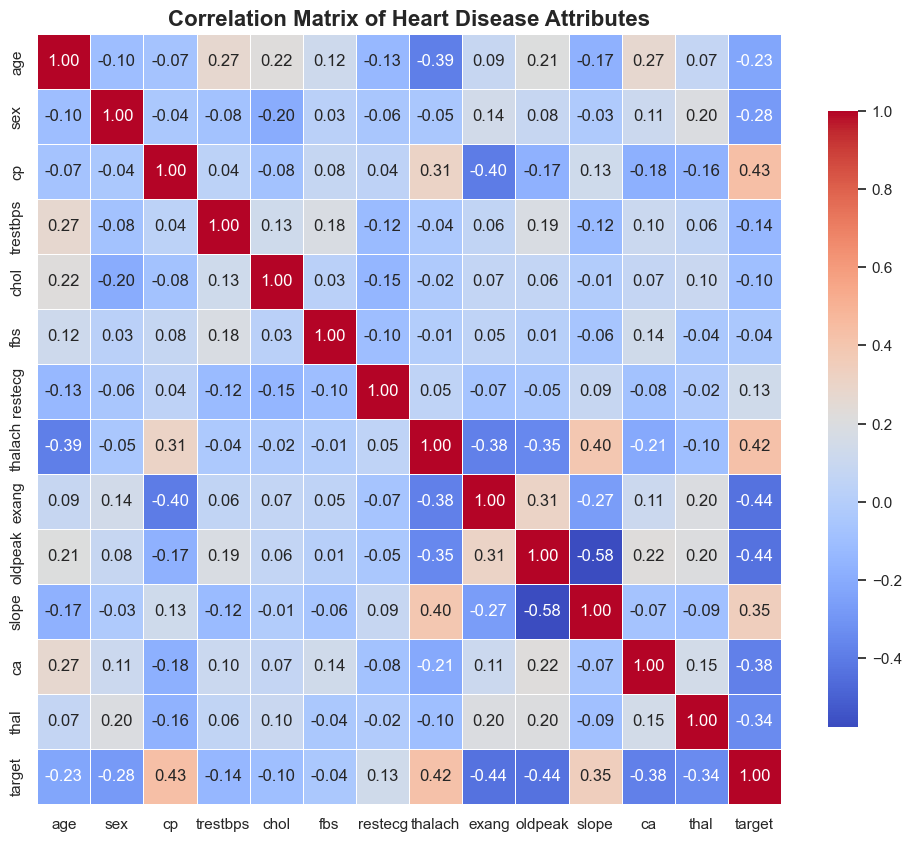

In [7]:
# The Correlation Matrix ->
# Near 1.0 (Dark Red/Warm): Strong positive correlation (as X goes up, Y goes up).
# Near -1.0 (Dark Blue/Cool): Strong negative correlation (as X goes up, Y goes down).
# Near 0 (White/Neutral): No relationship at all.

# Calculate the mathematical correlation between all columns
corr_matrix = df.corr()

# Set up the matplotlib canvas (making it large so the numbers fit)
plt.figure(figsize=(12, 10))

# Draw the Heatmap using Seaborn
sns.heatmap(
    corr_matrix, 
    annot=True,         # Prints the actual math numbers inside the boxes
    cmap='coolwarm',    # A great color theme for spotting negative vs positive
    fmt=".2f",          # Formats the numbers to 2 decimal places
    linewidths=0.5,     # Adds a clean border between boxes
    cbar_kws={"shrink": .8} # Shrinks the color legend slightly for neatness
)

plt.title("Correlation Matrix of Heart Disease Attributes", fontsize=16, fontweight='bold')
plt.show()

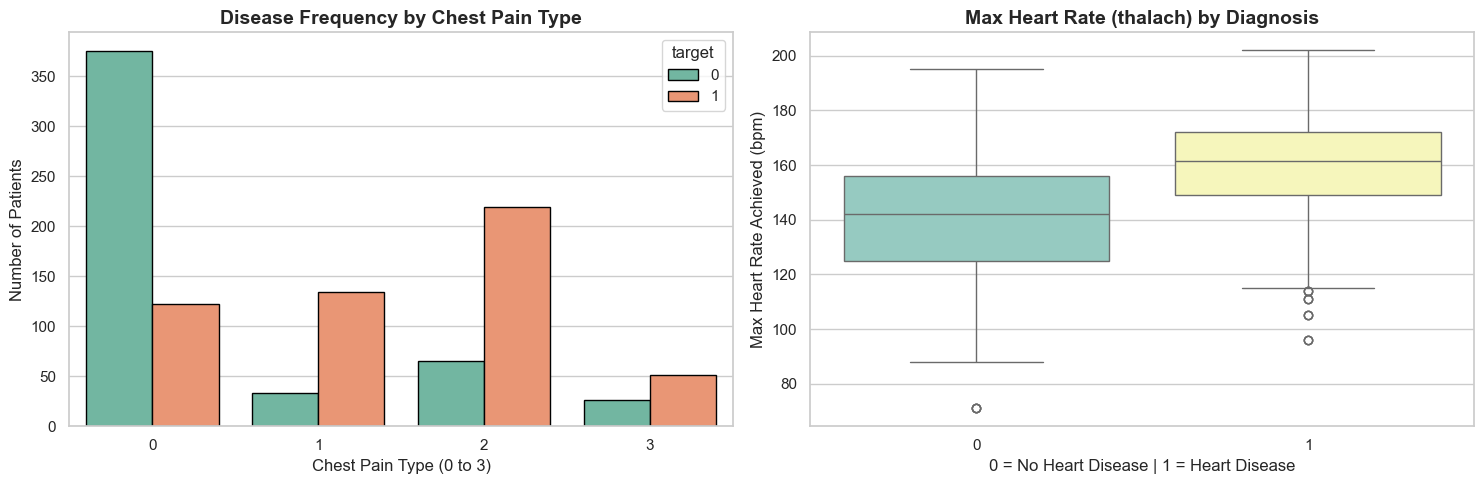

In [8]:
# Chest pain type analysis ->

fig, ax = plt.subplots(1, 2, figsize=(15, 5)) #creating 2 subplots(1row, 2columns and figure size/ window size will be 15 inches wide & 5 inches tall...

# Chart 1: Chest Pain Type vs. Diagnosis (Categorical)
sns.countplot(
    data=df, 
    x='cp', 
    hue='target', 
    palette='Set2', 
    ax=ax[0], 
    edgecolor='black'
)
ax[0].set_title("Disease Frequency by Chest Pain Type", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Chest Pain Type (0 to 3)")
ax[0].set_ylabel("Number of Patients")

# Chart 2: Max Heart Rate vs. Diagnosis (Numerical Distribution) 
# We use a Boxplot here to see the median, spread, and outliers of the heart rates
sns.boxplot(
    data=df, 
    x='target', 
    y='thalach', 
    hue='target',
    palette='Set3', 
    ax=ax[1],
    legend=False
)
ax[1].set_title("Max Heart Rate (thalach) by Diagnosis", fontsize=14, fontweight='bold')
ax[1].set_xlabel("0 = No Heart Disease | 1 = Heart Disease")
ax[1].set_ylabel("Max Heart Rate Achieved (bpm)")

plt.tight_layout()
plt.show()

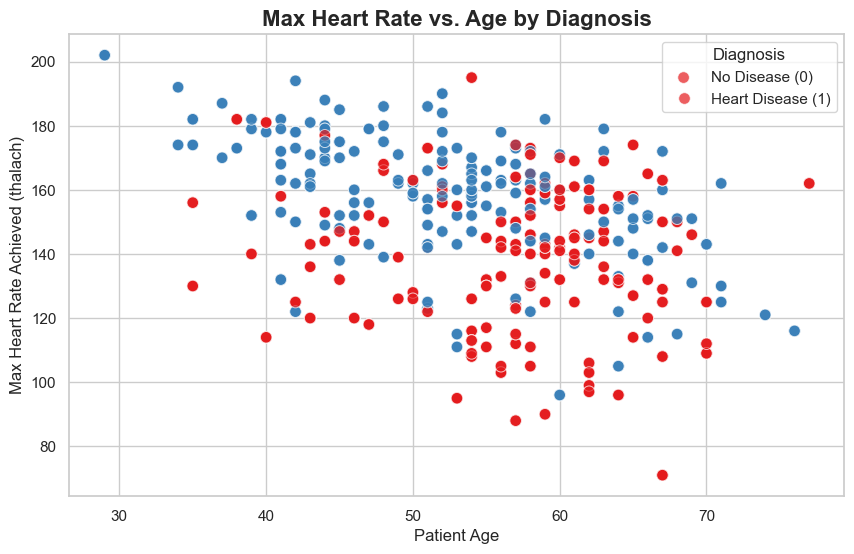

In [9]:
# Max heart rate vs age scatter plot ->
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='age', 
    y='thalach', 
    hue='target', 
    palette='Set1',   # Red and Blue to match the earlier charts
    alpha=0.7,        
    edgecolor='white',
    s=70              # Increases the size of the dots slightly
)

plt.title("Max Heart Rate vs. Age by Diagnosis", fontsize=16, fontweight='bold')
plt.xlabel("Patient Age", fontsize=12)
plt.ylabel("Max Heart Rate Achieved (thalach)", fontsize=12)

plt.legend(title="Diagnosis", labels=['No Disease (0)', 'Heart Disease (1)'])

plt.show()